## on normal data

## on a image:

In [35]:

import cv2
import numpy as np

# Load image as NumPy array
image = cv2.imread('macau.jpg')
single_channel = cv2.imread('macau.jpg', cv2.IMREAD_GRAYSCALE)



In [36]:
single_channel.shape

(1109, 740)

In [39]:
new_width=40
new_height=40

In [40]:
resized_image = cv2.resize(single_channel, (new_width, new_height))

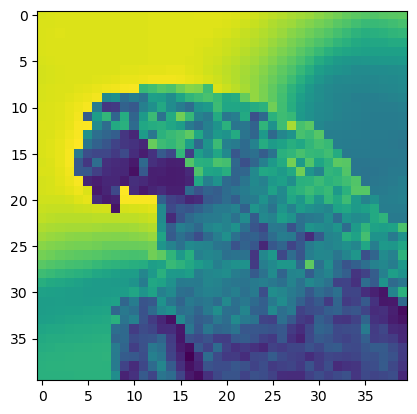

In [41]:
plt.imshow(resized_image)

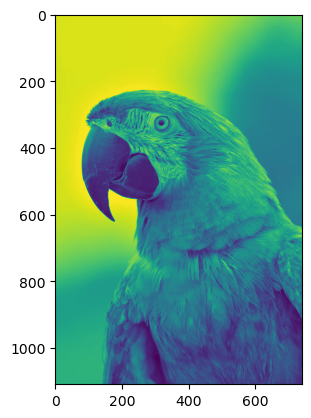

In [37]:
plt.imshow(single_channel)

In [50]:
from PIL import Image

In [55]:
import cv2

# Load an image
img = cv2.imread("data.jpeg")

# Save the image
cv2.imwrite("cute.jpeg", img) 

True

In [57]:
img.shape

(3560, 5360, 3)

In [61]:
single_c = cv2.imread('cute.jpeg', cv2.IMREAD_GRAYSCALE)


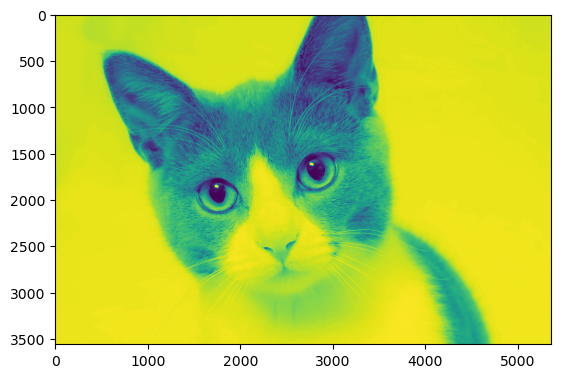

In [59]:
plt.imshow(single_channel)

In [54]:
img.shape

AttributeError: 'JpegImageFile' object has no attribute 'shape'

In [51]:


# Save the image to a new file
# The format is inferred from the extension (e.g., .png, .gif)
single_channel.save("piku.png") 

AttributeError: 'numpy.ndarray' object has no attribute 'save'

In [34]:

import numpy as np

def positional_encoding_2d(height, width, d_model):
    """
    Generate 2D positional encoding for a single-channel image.
    
    Args:
        height (int): Height of the image
        width (int): Width of the image
        d_model (int): Dimension of the positional encoding (must be even)
    
    Returns:
        np.ndarray: Positional encoding of shape (height, width, d_model)
    """
    if d_model % 2 != 0:
        raise ValueError("d_model must be even")
    
    # Initialize the positional encoding array
    pe = np.zeros((height, width, d_model))
    
    # Calculate position indices
    pos_y = np.arange(height).reshape(-1, 1, 1)  # Shape: (height, 1, 1)
    pos_x = np.arange(width).reshape(1, -1, 1)  # Shape: (1, width, 1)
    
    # Calculate the divisor term
    div_term = np.exp(np.arange(0, d_model//4, 1) * (-np.log(10000.0) / (d_model//4)))
    div_term = div_term.reshape(1, 1, -1)  # Shape: (1, 1, d_model//4)
    
    # Calculate positional encodings for y dimension
    pe[:, :, 0::4] = np.sin(pos_y * div_term)  # y-sin
    pe[:, :, 1::4] = np.cos(pos_y * div_term)  # y-cos
    
    # Calculate positional encodings for x dimension
    pe[:, :, 2::4] = np.sin(pos_x * div_term)  # x-sin
    pe[:, :, 3::4] = np.cos(pos_x * div_term)  # x-cos
    
    return pe

def apply_positional_encoding(image, d_model):
    """
    Apply positional encoding to a single-channel image.
    
    Args:
        image (np.ndarray): Single-channel image of shape (height, width)
        d_model (int): Dimension of the positional encoding
    
    Returns:
        np.ndarray: Image with positional encoding of shape (height, width, d_model + 1)
    """
    height, width = image.shape
    print(image.shape)
    pe = positional_encoding_2d(height, width, d_model)
    
    # Expand image to match output dimensions
    image_expanded = np.expand_dims(image, axis=-1)
    
    # Concatenate image with positional encodings
    result = np.concatenate([image_expanded, pe], axis=-1)
    
    return result



(1109, 740)
Input image shape: (1109, 740)
Encoded image shape: (1109, 740, 33)


In [ ]:
# Example usage
if __name__ == "__main__":
    # Create a sample single-channel image (e.g., 64x64 grayscale)
    
    
    # Set the dimension for positional encoding
    d_model = 32  # Must be even
    
    # Apply positional encoding
    encoded_image = apply_positional_encoding(single_channel, d_model)
    
    print(f"Input image shape: {single_channel.shape}")
    print(f"Encoded image shape: {encoded_image.shape}")


In [26]:
encoded_image;

In [32]:
# plt.imshow(encoded_image)

In [42]:
encoded_image = apply_positional_encoding(resized_image, d_model)

(40, 40)


In [43]:
encoded_image.shape

(40, 40, 33)

Positional encoding shape: (196, 768)
Sample encoding for first patch:
[0. 0. 0. 0. 0.]


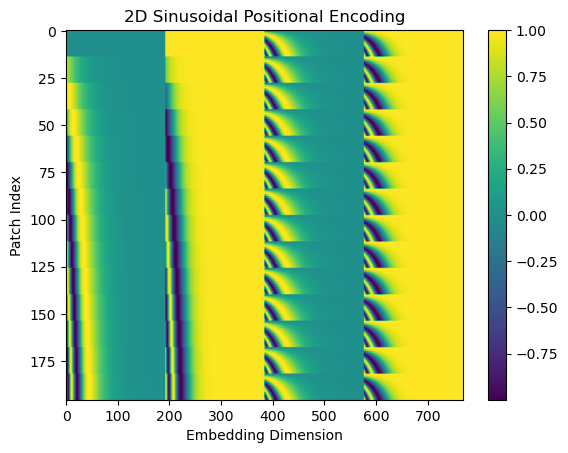

In [45]:
import numpy as np

def get_2d_sinusoidal_pos_encoding(num_patches_h, num_patches_w, dim):
    """
    Generate 2D sinusoidal positional encodings for image patches.
    
    Args:
        num_patches_h (int): Number of patches along height.
        num_patches_w (int): Number of patches along width.
        dim (int): Dimension of each patch embedding (must be divisible by 4).
    
    Returns:
        np.ndarray: Positional encoding matrix of shape (num_patches_h * num_patches_w, dim).
    """
    assert dim % 4 == 0, "Embedding dimension must be divisible by 4 for 2D encoding"
    
    # Initialize the positional encoding matrix
    pos_encoding = np.zeros((num_patches_h * num_patches_w, dim))
    
    # Generate position indices for height and width
    h_indices = np.repeat(np.arange(num_patches_h), num_patches_w)
    w_indices = np.tile(np.arange(num_patches_w), num_patches_h)
    
    # Compute divisor term for sinusoidal encoding (use dim//4 for each quarter)
    div_term = np.exp(np.arange(0, dim // 4, 1) * (-np.log(10000.0) / (dim // 4)))
    
    # Encode height (x-coordinate)
    pos_encoding[:, 0:dim//4] = np.sin(h_indices[:, None] * div_term)
    pos_encoding[:, dim//4:dim//2] = np.cos(h_indices[:, None] * div_term)
    
    # Encode width (y-coordinate)
    pos_encoding[:, dim//2:3*dim//4] = np.sin(w_indices[:, None] * div_term)
    pos_encoding[:, 3*dim//4:dim] = np.cos(w_indices[:, None] * div_term)
    
    return pos_encoding

# Example usage
def main():
    # Example parameters
    image_size = 224  # Image height and width (224x224)
    patch_size = 16   # Patch size (16x16)
    embedding_dim = 768  # Dimension of patch embeddings
    
    # Calculate number of patches
    num_patches_h = image_size // patch_size  # 224 / 16 = 14
    num_patches_w = image_size // patch_size  # 224 / 16 = 14
    
    # Generate positional encodings
    pos_enc = get_2d_sinusoidal_pos_encoding(num_patches_h, num_patches_w, embedding_dim)
    
    # Print shape and sample values
    print(f"Positional encoding shape: {pos_enc.shape}")
    print(f"Sample encoding for first patch:\n{pos_enc[0, :5]}")
    
    # Optional: Visualize the positional encodings (requires matplotlib)
    try:
        import matplotlib.pyplot as plt
        plt.imshow(pos_enc, aspect='auto')
        plt.title("2D Sinusoidal Positional Encoding")
        plt.xlabel("Embedding Dimension")
        plt.ylabel("Patch Index")
        plt.colorbar()
        plt.show()
    except ImportError:
        print("Matplotlib not installed, skipping visualization.")

if __name__ == "__main__":
    main()

Image not found at sample_image.jpg. Generating a dummy image.
Positional encoding shape: (196, 768)
Sample encoding for first patch:
[0. 0. 0. 0. 0.]


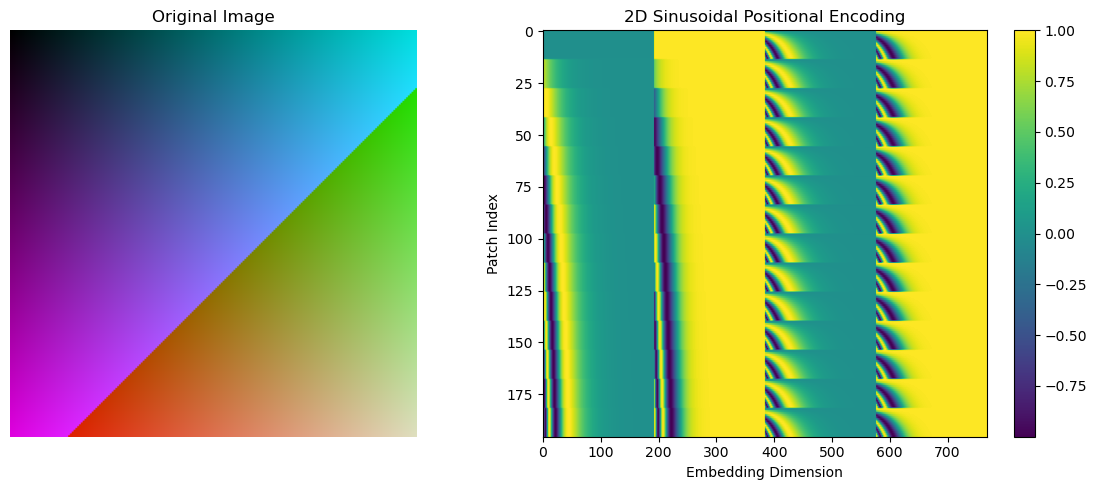

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_2d_sinusoidal_pos_encoding(num_patches_h, num_patches_w, dim):
    """
    Generate 2D sinusoidal positional encodings for image patches.
    
    Args:
        num_patches_h (int): Number of patches along height.
        num_patches_w (int): Number of patches along width.
        dim (int): Dimension of each patch embedding (must be divisible by 4).
    
    Returns:
        np.ndarray: Positional encoding matrix of shape (num_patches_h * num_patches_w, dim).
    """
    assert dim % 4 == 0, "Embedding dimension must be divisible by 4 for 2D encoding"
    
    # Initialize the positional encoding matrix
    pos_encoding = np.zeros((num_patches_h * num_patches_w, dim))
    
    # Generate position indices for height and width
    h_indices = np.repeat(np.arange(num_patches_h), num_patches_w)
    w_indices = np.tile(np.arange(num_patches_w), num_patches_h)
    
    # Compute divisor term for sinusoidal encoding (use dim//4 for each quarter)
    div_term = np.exp(np.arange(0, dim // 4, 1) * (-np.log(10000.0) / (dim // 4)))
    
    # Encode height (x-coordinate)
    pos_encoding[:, 0:dim//4] = np.sin(h_indices[:, None] * div_term)
    pos_encoding[:, dim//4:dim//2] = np.cos(h_indices[:, None] * div_term)
    
    # Encode width (y-coordinate)
    pos_encoding[:, dim//2:3*dim//4] = np.sin(w_indices[:, None] * div_term)
    pos_encoding[:, 3*dim//4:dim] = np.cos(w_indices[:, None] * div_term)
    
    return pos_encoding

def load_and_preprocess_image(image_path, image_size):
    """
    Load an image and resize it to the specified size.
    
    Args:
        image_path (str): Path to the image file or None for a dummy image.
        image_size (int): Desired height and width of the image.
    
    Returns:
        np.ndarray: Resized image as a NumPy array.
    """
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize((image_size, image_size))
        img_array = np.array(img)
    except FileNotFoundError:
        print(f"Image not found at {image_path}. Generating a dummy image.")
        # Create a dummy gradient image
        img_array = np.zeros((image_size, image_size, 3), dtype=np.uint8)
        for i in range(image_size):
            for j in range(image_size):
                img_array[i, j] = [i % 255, j % 255, (i + j) % 255]
    return img_array

def main():
    # Example parameters
    image_path = "sample_image.jpg"  # Replace with your image path or set to None for dummy
    image_size = 224  # Image height and width (224x224)
    patch_size = 16   # Patch size (16x16)
    embedding_dim = 768  # Dimension of patch embeddings
    
    # Load and preprocess the image
    img_array = load_and_preprocess_image(image_path, image_size)
    
    # Calculate number of patches
    num_patches_h = image_size // patch_size  # 224 / 16 = 14
    num_patches_w = image_size // patch_size  # 224 / 16 = 14
    
    # Generate positional encodings
    pos_enc = get_2d_sinusoidal_pos_encoding(num_patches_h, num_patches_w, embedding_dim)
    
    # Print shape and sample values
    print(f"Positional encoding shape: {pos_enc.shape}")
    print(f"Sample encoding for first patch:\n{pos_enc[0, :5]}")
    
    # Visualize the original image and positional encodings
    try:
        # Create a figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot the original image
        ax1.imshow(img_array)
        ax1.set_title("Original Image")
        ax1.axis('off')
        
        # Plot the positional encoding
        im = ax2.imshow(pos_enc, aspect='auto')
        ax2.set_title("2D Sinusoidal Positional Encoding")
        ax2.set_xlabel("Embedding Dimension")
        ax2.set_ylabel("Patch Index")
        fig.colorbar(im, ax=ax2)
        
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("Matplotlib or PIL not installed, skipping visualization.")

if __name__ == "__main__":
    main()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_2d_sinusoidal_pos_encoding(num_patches_h, num_patches_w, dim):
    """
    Generate 2D sinusoidal positional encodings for image patches.
    
    Args:
        num_patches_h (int): Number of patches along height.
        num_patches_w (int): Number of patches along width.
        dim (int): Dimension of each patch embedding (must be divisible by 4).
    
    Returns:
        np.ndarray: Positional encoding matrix of shape (num_patches_h * num_patches_w, dim).
    """
    assert dim % 4 == 0, "Embedding dimension must be divisible by 4 for 2D encoding"
    
    # Initialize the positional encoding matrix
    pos_encoding = np.zeros((num_patches_h * num_patches_w, dim))
    
    # Generate position indices for height and width
    h_indices = np.repeat(np.arange(num_patches_h), num_patches_w)
    w_indices = np.tile(np.arange(num_patches_w), num_patches_h)
    
    # Compute divisor term for sinusoidal encoding (use dim//4 for each quarter)
    div_term = np.exp(np.arange(0, dim // 4, 1) * (-np.log(10000.0) / (dim // 4)))
    
    # Encode height (x-coordinate)
    pos_encoding[:, 0:dim//4] = np.sin(h_indices[:, None] * div_term)
    pos_encoding[:, dim//4:dim//2] = np.cos(h_indices[:, None] * div_term)
    
    # Encode width (y-coordinate)
    pos_encoding[:, dim//2:3*dim//4] = np.sin(w_indices[:, None] * div_term)
    pos_encoding[:, 3*dim//4:dim] = np.cos(w_indices[:, None] * div_term)
    
    return pos_encoding

def load_and_preprocess_image(image_path, image_size):
    """
    Load an image and resize it to the specified size.
    
    Args:
        image_path (str): Path to the image file or None for a dummy image.
        image_size (int): Desired height and width of the image.
    
    Returns:
        np.ndarray: Resized image as a NumPy array.
    """
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize((image_size, image_size))
        img_array = np.array(img)
    except FileNotFoundError:
        print(f"Image not found at {image_path}. Generating a dummy image.")
        # Create a dummy gradient image
        img_array = np.zeros((image_size, image_size, 3), dtype=np.uint8)
        for i in range(image_size):
            for j in range(image_size):
                img_array[i, j] = [i % 255, j % 255, (i + j) % 255]
    return img_array



 000000.jpg


Positional encoding shape: (196, 768)
Sample encoding for first patch:
[0. 0. 0. 0. 0.]


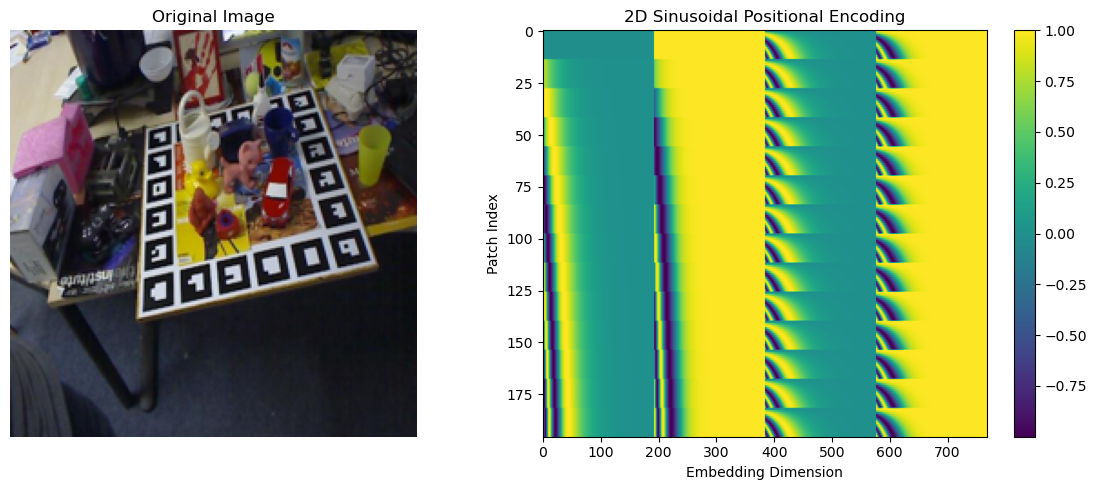

In [7]:
def main():
    # Example parameters
    # image_path = "cute.jpeg"  # Replace with your image path or set to None for dummy
    image_path=input()
    image_size = 224  # Image height and width (224x224)
    patch_size = 16   # Patch size (16x16)
    embedding_dim = 768  # Dimension of patch embeddings
    
    # Load and preprocess the image
    img_array = load_and_preprocess_image(image_path, image_size)
    
    # Calculate number of patches
    num_patches_h = image_size // patch_size  # 224 / 16 = 14
    num_patches_w = image_size // patch_size  # 224 / 16 = 14
    
    # Generate positional encodings
    pos_enc = get_2d_sinusoidal_pos_encoding(num_patches_h, num_patches_w, embedding_dim)
    
    # Print shape and sample values
    print(f"Positional encoding shape: {pos_enc.shape}")
    print(f"Sample encoding for first patch:\n{pos_enc[0, :5]}")
    
    # Visualize the original image and positional encodings
    try:
        # Create a figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot the original image
        ax1.imshow(img_array)
        ax1.set_title("Original Image")
        ax1.axis('off')
        
        # Plot the positional encoding
        im = ax2.imshow(pos_enc, aspect='auto')
        ax2.set_title("2D Sinusoidal Positional Encoding")
        ax2.set_xlabel("Embedding Dimension")
        ax2.set_ylabel("Patch Index")
        fig.colorbar(im, ax=ax2)
        
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("Matplotlib or PIL not installed, skipping visualization.")

if __name__ == "__main__":
    main()